In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-dadhe -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
sudo: fc-dadhe: command not found


In [1]:
%pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 28.1 MB/s eta 0:00:00


In [2]:
%pip install python-mecab-ko

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.6/579.6 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 45.6 MB/s eta 0:00:00


In [2]:
from konlpy.corpus import kolaw
# data = kolaw.open('constitution.txt').readlines() # 한줄씩 list로 반환
data = kolaw.open('constitution.txt').read()
print('글자수 : ', len(data))

글자수 :  18884


In [3]:
from mecab import MeCab
analyzer = MeCab() # mecab, kkma 의 경우 NNG, NNP/ okt의 경우 None
noun_list = analyzer.nouns(data)
noun_list = [word for word, tag in analyzer.pos(data) if tag in ('NNG', 'NNP')]
data_noun = ' '.join(noun_list)
print(data_noun[:20])

대한민국 헌법 역사 전통 국민 운동 


(1124, 720, 3)


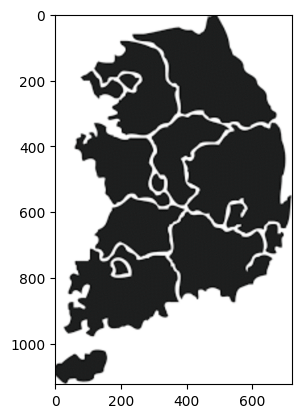

In [4]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
img = Image.open('/content/drive/MyDrive/nlp_ex/data/south_korea.png').convert('RGB')
mask = np.array(img)
plt.imshow(mask)
print(mask.shape)

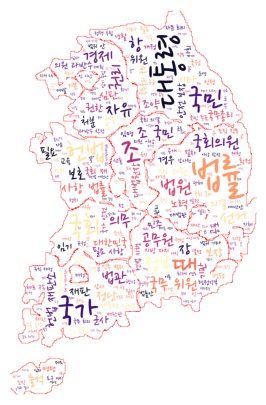

In [6]:
from wordcloud import WordCloud
wordcloud = WordCloud(
    font_path='/content/drive/MyDrive/nlp_ex/data/NanumPenScript-Regular.ttf', # 폰트
    background_color='white', # 배경색
    max_words=300, # 표시될 단어의 최대 갯수
    #relative_scaling=0.6 # 단어 빈도에 따른 크기 차이 조정
    colormap= 'magma', # 글씨 컬러맵
    mask=mask,
    contour_color='red',
    contour_width=1
)
wordcloud.generate(data_noun)
plt.figure(figsize=(18,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [7]:
wordcloud.to_file('/content/drive/MyDrive/nlp_ex/data/korea.jpg')

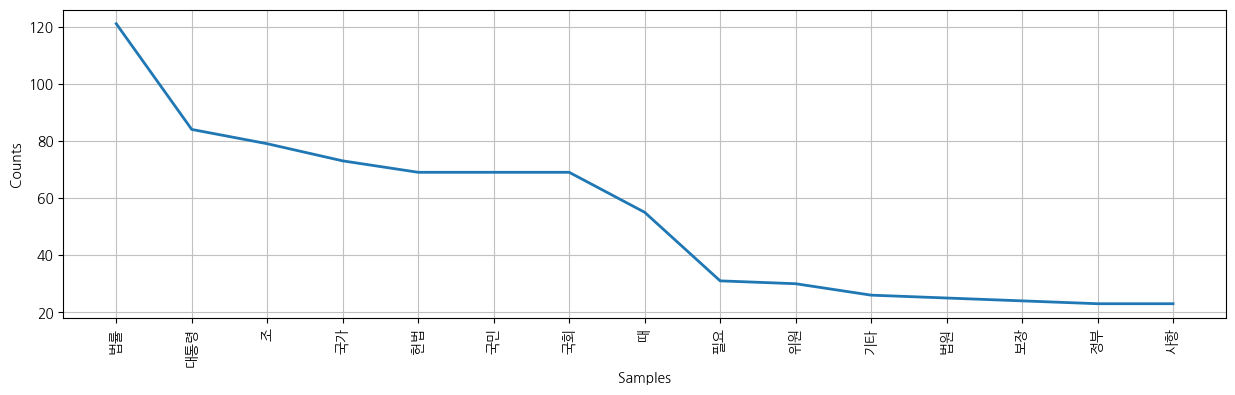

In [8]:
# 단어의 빈도수 그래프 시각화(nltk.Text)
import nltk
data_text = nltk.Text(noun_list)
plt.figure(figsize=(15,4))
plt.rc('font', family='NanumGothic') # 코랩 한글처리
data_text.plot(15)
plt.show()